1.	Load a simple dataset (like iris, or make_blobs) using sklearn.datasets.


X (features):
 [[ 2.24823735  1.07410715]
 [ 5.12395668  0.73232327]
 [ 4.6766441   2.72016712]
 [-4.10265319  9.72467477]
 [ 5.06136664  1.0391204 ]
 [ 7.85579497  2.92404822]
 [ 4.81015485  2.9663657 ]
 [ 3.92746087  0.99317584]
 [-3.17897005 10.29888432]
 [ 5.92636827  1.73326189]]
y (labels):
 [1 1 1 0 1 1 1 1 0 1]


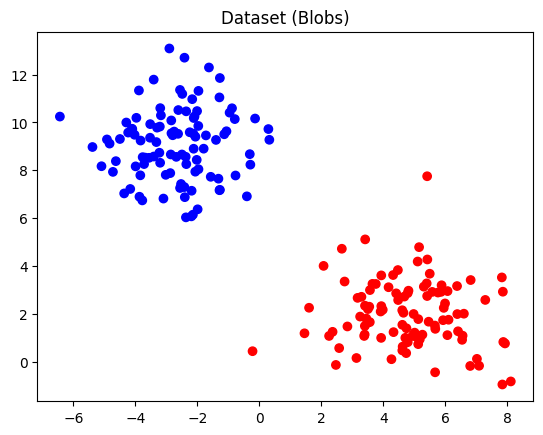

In [ ]:
# Step 1: Load dataset (2D for visualization)
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)


# Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title("Dataset (Blobs)")
plt.show()

In [15]:
# Step 2: Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Step 3: Train linear SVM
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1)
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


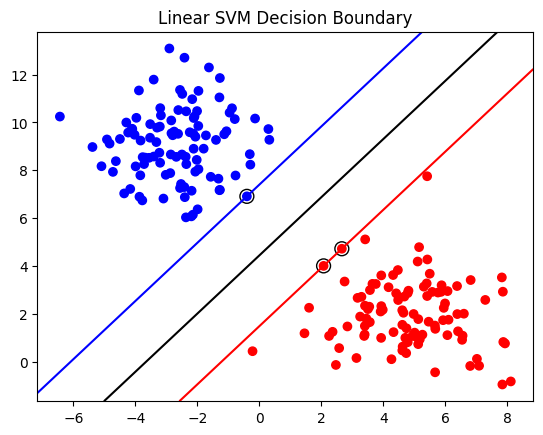

In [ ]:
# Step 4: Decision boundary function
import numpy as np

def plot_decision_boundary(model, X, y, title):

    # Plot the original data points X contains the coordinates (x,y) and y contains the class labels [0,1]
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
    
    # gca() = "Get Current Axis"
    # Gives access to plot area for further customization
    ax = plt.gca()

    # limits of the plot area
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 30 points in each direction to create a grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)

    # create a grid of points and evaluate the decision function for each point
    YY, XX = np.meshgrid(yy, xx)

    # It converts 2D meshgrid arrays (XX, YY) into a single 2D table where each row is a point in the grid
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # decision_function gives the distance of the samples to the separating hyperplane
    Z = model.decision_function(xy).reshape(XX.shape)

    # Plot decision boundary

    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['blue', 'black', 'red'])
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='k')

    plt.title(title)
    plt.show()

# Plot
plot_decision_boundary(model, X, y, "Linear SVM Decision Boundary")

In [18]:
# Step 5: Print support vectors
print("Support Vectors:\n", model.support_vectors_)

# Interpretation:
# These are the points closest to the decision boundary.
# They define the margin and influence the classifier.

Support Vectors:
 [[-0.40500616  6.91150953]
 [ 2.65952903  4.72035783]
 [ 2.07017704  4.00397825]]


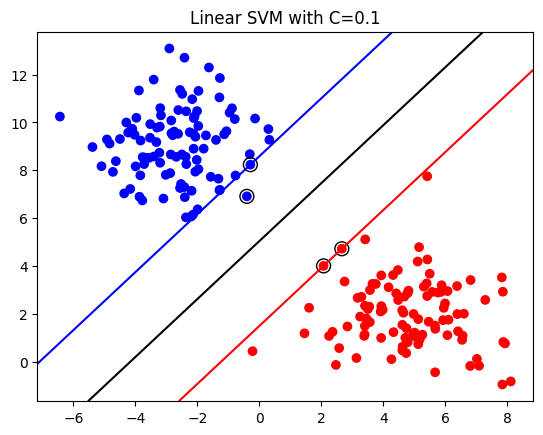

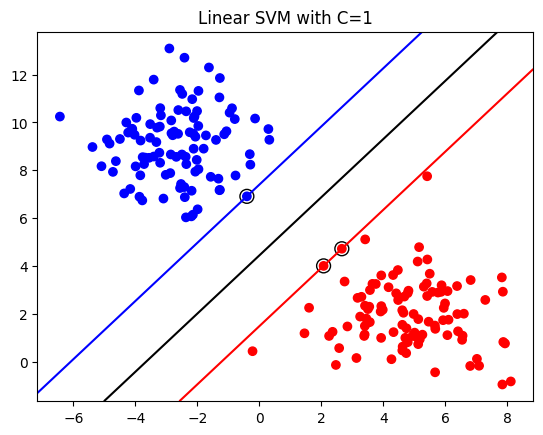

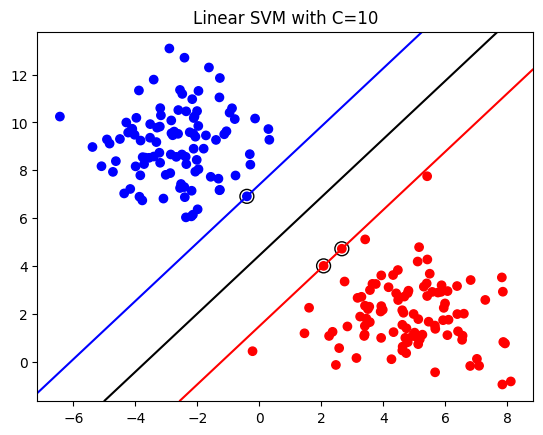

In [19]:
# Step 6: Effect of C
C_values = [0.1, 1, 10]

for C in C_values:
    model = SVC(kernel='linear', C=C)
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X, y, f"Linear SVM with C={C}")

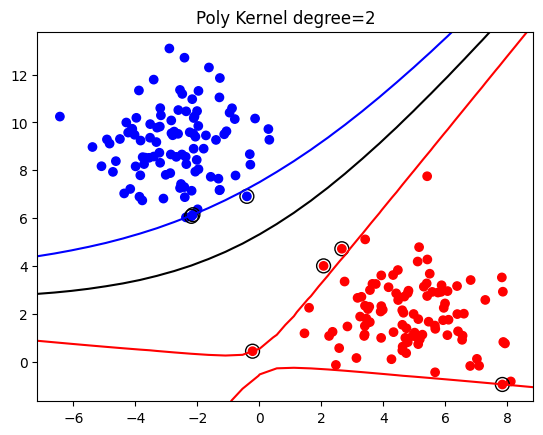

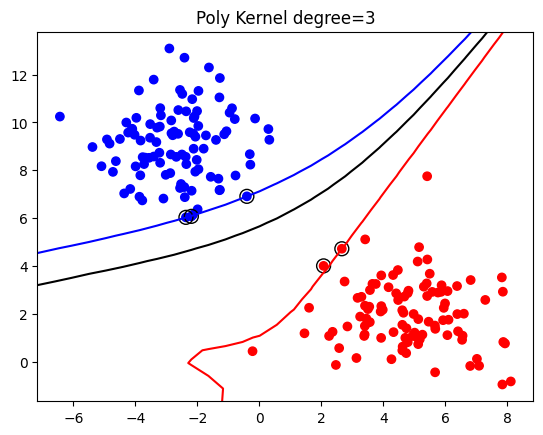

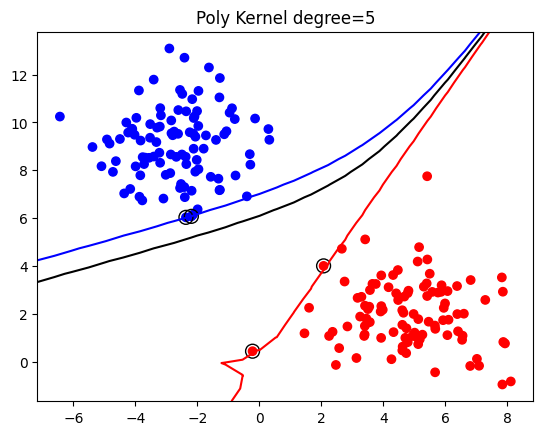

In [20]:
# Step 7: Polynomial kernel
degrees = [2, 3, 5]

for d in degrees:
    model = SVC(kernel='poly', degree=d)
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X, y, f"Poly Kernel degree={d}")

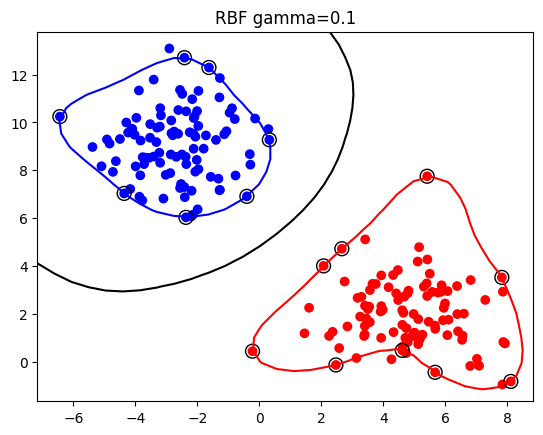

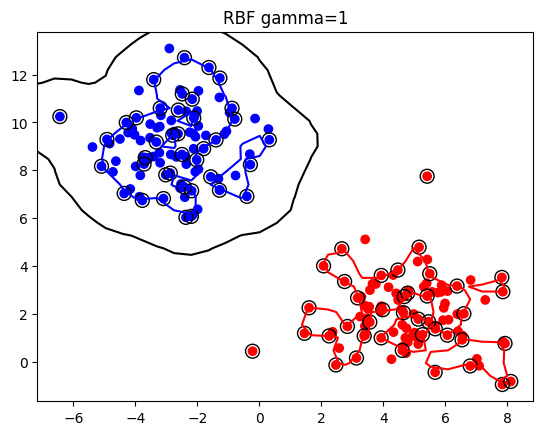

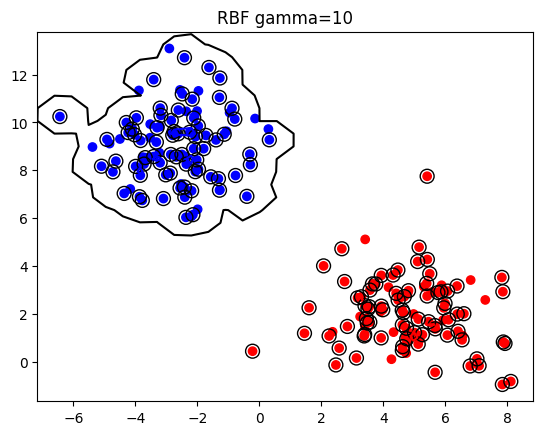

In [21]:
# Step 8: RBF kernel
gamma_values = [0.1, 1, 10]

for g in gamma_values:
    model = SVC(kernel='rbf', gamma=g)
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X, y, f"RBF gamma={g}")

In [22]:
# Step 9: Compare kernels
from sklearn.metrics import accuracy_score

kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{k} kernel accuracy: {acc:.2f}")

linear kernel accuracy: 1.00
poly kernel accuracy: 1.00
rbf kernel accuracy: 1.00


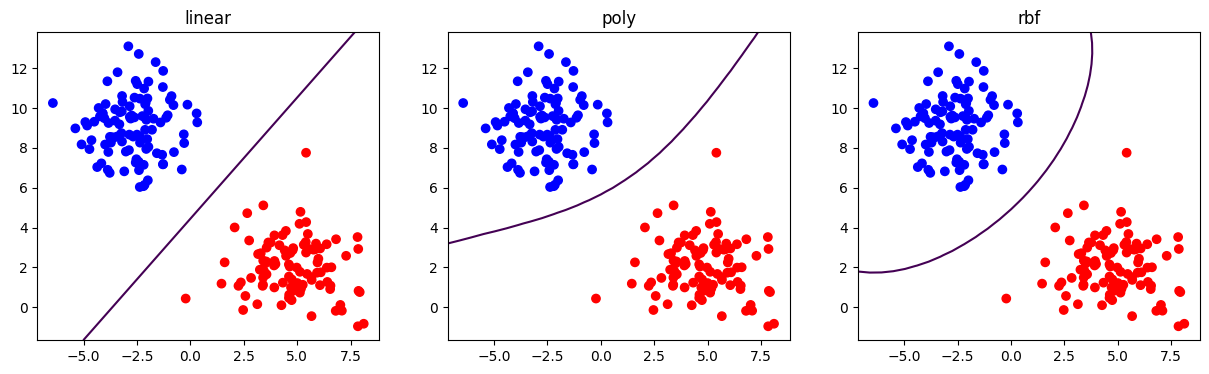

In [23]:
# Step 10: Subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

kernels = ['linear', 'poly', 'rbf']

for i, k in enumerate(kernels):
    model = SVC(kernel=k)
    model.fit(X_train, y_train)

    ax = axes[i]
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])
    ax.set_title(k)

plt.show()

In [24]:
# Step 11: Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

print("Accuracy after scaling:", model.score(X_test, y_test))

Accuracy after scaling: 1.0


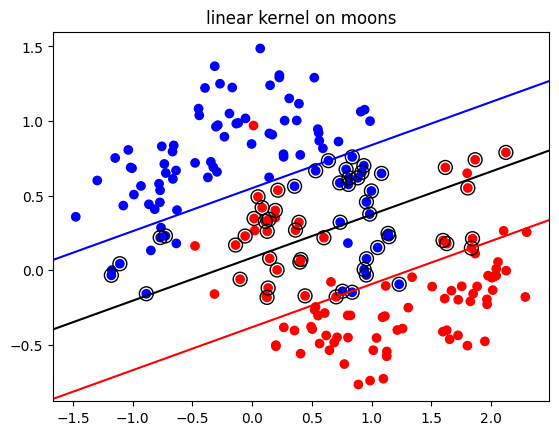

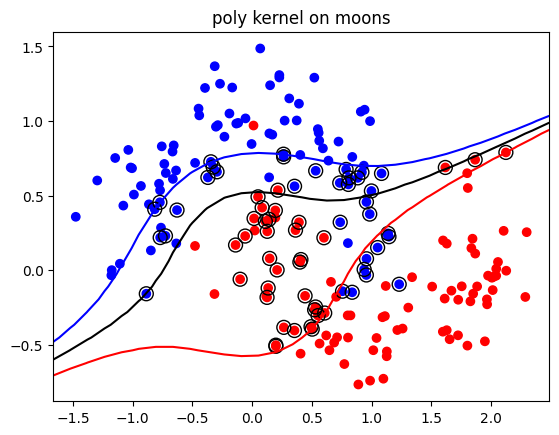

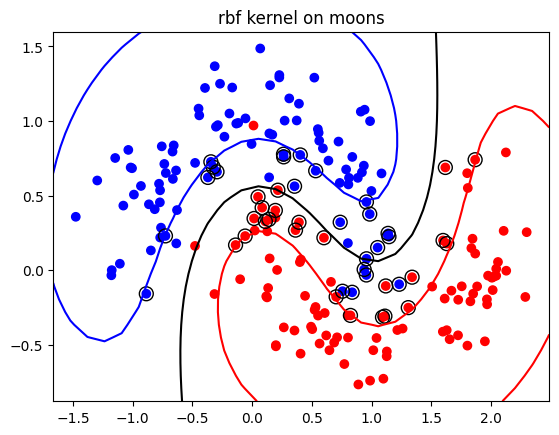

In [25]:
# Step 12: Nonlinear dataset
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X, y, f"{k} kernel on moons")

In [26]:
# Step 13: Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.1, 1, 10]
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}
Best Score: 0.96875


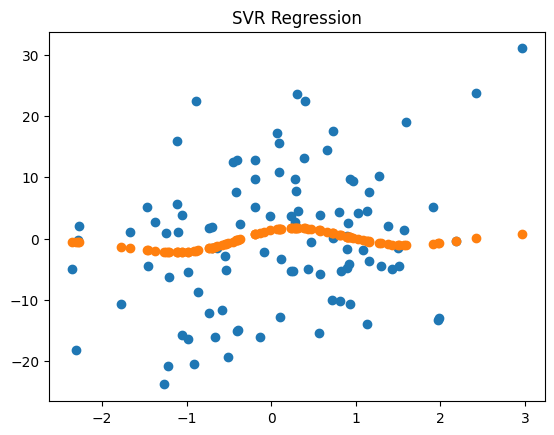

In [27]:
# Step 14: SVR
from sklearn.datasets import make_regression
from sklearn.svm import SVR

X, y = make_regression(n_samples=100, n_features=1, noise=10)

model = SVR(kernel='rbf')
model.fit(X, y)

# Plot
plt.scatter(X, y)
plt.scatter(X, model.predict(X))
plt.title("SVR Regression")
plt.show()

In [28]:
# Step 15: Real dataset
from sklearn.datasets import load_digits
from sklearn.metrics import classification_report, confusion_matrix

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:\n", classification_report(y_test, preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))

Accuracy: 0.9861111111111112

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360


Confusion Matrix:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [